# Visualizing an FCM-Attention CNN, Step by Step

This notebook is a **pure visualization companion** to `fcm-cnn-digits.ipynb`. Nothing here is trained — every kernel is hand-crafted so that each intermediate feature map stays interpretable, and every operation is implemented from scratch in plain NumPy so the math is visible.

Pipeline mirrored from the real model:

| Real model (`FCM_CNN`) | This notebook |
|---|---|
| RGB 28×28 input, `conv1` 3×3 → 64 maps | Grayscale 28×28 input, one hand-made 3×3 kernel → **1** map |
| MaxPool 28→14 | MaxPool 28→14 |
| `conv2` 5×5 → 128 maps | Two hand-made 5×5 kernels → **2** maps |
| MaxPool 14→7 | MaxPool 14→7 |
| `conv3` 7×7 → 256 maps | Four hand-made 7×7 Gabor kernels → **4** maps |
| `FCMLayer` (fuzzy c-means attention) | Same FCM math, run and visualized step by step |

Spatial sizes (28→14→7) and the padding scheme match the real network exactly; only the *number* of feature maps and the *source* of the kernel weights (hand-crafted vs. learned) differ, so every step stays something you can look at and understand.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

np.set_printoptions(suppress=True)

# ---- CONFIG ----
# Folder containing sample images named '0.jpg' ... '9.jpg' (one per class).
DATA_DIR = "sample_data"


## Choose what to visualize

Pick a digit, and set the two FCM hyperparameters that the assignment asks to be user-controlled: the **number of iterations** and the **fuzziness `m`**. `K` (number of clusters) is exposed too since it's needed to run FCM, but the important controls are iterations and fuzziness.

After changing a value here, re-run the cells below (`Run > Run All Below`) to see the effect.

In [2]:
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("ipywidgets not available -- falling back to plain values. "
          "Edit the *_DEFAULT constants above and re-run instead.")

DIGIT_DEFAULT = '4'
N_CLUSTERS_DEFAULT = 4
N_ITER_DEFAULT = 10
FUZZINESS_DEFAULT = 2.0

if HAS_WIDGETS:
    digit_dropdown = widgets.Dropdown(
        options=[str(i) for i in range(10)], value=DIGIT_DEFAULT, description='Digit:')
    n_clusters_slider = widgets.IntSlider(
        value=N_CLUSTERS_DEFAULT, min=2, max=6, step=1, description='K (clusters):',
        style={'description_width': 'initial'})
    n_iter_slider = widgets.IntSlider(
        value=N_ITER_DEFAULT, min=1, max=15, step=1, description='FCM iterations:',
        style={'description_width': 'initial'})
    fuzziness_slider = widgets.FloatSlider(
        value=FUZZINESS_DEFAULT, min=1.1, max=4.0, step=0.1, description='Fuzziness m:',
        style={'description_width': 'initial'})
    display(widgets.VBox([digit_dropdown, n_clusters_slider, n_iter_slider, fuzziness_slider]))
else:
    class _Val:
        def __init__(self, v):
            self.value = v
    digit_dropdown = _Val(DIGIT_DEFAULT)
    n_clusters_slider = _Val(N_CLUSTERS_DEFAULT)
    n_iter_slider = _Val(N_ITER_DEFAULT)
    fuzziness_slider = _Val(FUZZINESS_DEFAULT)
    print(f"digit={digit_dropdown.value}  K={n_clusters_slider.value}  "
          f"iters={n_iter_slider.value}  m={fuzziness_slider.value}")


## Helper functions

Manual (from-scratch) convolution, max pooling, a Gabor-kernel generator for the 7×7 stage, and small plotting / "show your work" helpers. Implementing convolution as an explicit sliding window (rather than calling a library) is what lets us print the exact patch/kernel/product for any pixel later on.

In [3]:
def conv2d(img, kernel, padding='same'):
    '''Manual 2D cross-correlation (the operation CNNs call "convolution") with zero padding.'''
    kh, kw = kernel.shape
    if padding == 'same':
        pad_h, pad_w = kh // 2, kw // 2
        img_p = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    else:
        img_p = img
    H, W = img.shape
    out = np.zeros((H, W), dtype=np.float32)
    for i in range(H):
        for j in range(W):
            patch = img_p[i:i+kh, j:j+kw]
            out[i, j] = np.sum(patch * kernel)
    return out

def relu(x):
    return np.maximum(0, x)

def maxpool2d(img, size=2, stride=2):
    H, W = img.shape
    out_h, out_w = H // size, W // size
    out = np.zeros((out_h, out_w), dtype=np.float32)
    for i in range(out_h):
        for j in range(out_w):
            out[i, j] = np.max(img[i*stride:i*stride+size, j*stride:j*stride+size])
    return out

def gabor_kernel(size, theta, sigma=2.5, lam=5.0, gamma=0.5, psi=0):
    '''Hand-made orientation-selective kernel (no learning involved).'''
    half = size // 2
    y, x = np.mgrid[-half:half+1, -half:half+1]
    x_theta = x*np.cos(theta) + y*np.sin(theta)
    y_theta = -x*np.sin(theta) + y*np.cos(theta)
    gb = np.exp(-(x_theta**2 + gamma**2*y_theta**2) / (2*sigma**2)) * np.cos(2*np.pi*x_theta/lam + psi)
    return gb.astype(np.float32)

def show_maps(maps, titles, suptitle, cmap='viridis', figsize_per=3.0):
    n = len(maps)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per*n, figsize_per + 0.4))
    if n == 1:
        axes = [axes]
    for ax, m, t in zip(axes, maps, titles):
        im = ax.imshow(m, cmap=cmap)
        ax.set_title(t, fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(suptitle, fontsize=12)
    plt.tight_layout()
    plt.show()

def explain_conv_example(img, kernel, output=None, position=None, pad=None):
    '''Prints a fully worked example of ONE convolution output value.'''
    kh, kw = kernel.shape
    if pad is None:
        pad = kh // 2
    img_p = np.pad(img, pad, mode='constant')
    if position is None:
        position = np.unravel_index(np.argmax(output), output.shape) if output is not None \
            else (img.shape[0]//2, img.shape[1]//2)
    r, c = position
    patch = img_p[r:r+kh, c:c+kw]
    product = patch * kernel
    result = product.sum()
    print(f"Worked example -- output pixel at row={r}, col={c}")
    print(f"\nInput patch under the kernel ({kh}x{kw}):")
    print(np.round(patch, 3))
    print(f"\nKernel weights ({kh}x{kw}):")
    print(np.round(kernel, 3))
    print(f"\nElement-wise product (patch * kernel):")
    print(np.round(product, 3))
    print(f"\nSum of all products -> output[{r},{c}] = {result:.4f}")
    print("\nFormula:  output[r,c] = sum_i sum_j patch[i,j] * kernel[i,j]")
    return result

def explain_maxpool_example(feat_map, pooled, position=None, size=2):
    if position is None:
        position = np.unravel_index(np.argmax(pooled), pooled.shape)
    r, c = position
    block = feat_map[r*size:r*size+size, c*size:c*size+size]
    result = block.max()
    print(f"Worked example -- output pixel at row={r}, col={c}")
    print(f"\n{size}x{size} block from the feature map:")
    print(np.round(block, 3))
    print(f"\nMax value in block = {result:.4f}  ->  pooled[{r},{c}] = {result:.4f}")
    print("\nFormula:  pooled[r,c] = max over the corresponding size x size block of the input")
    return result


## Step 0 — Load the original image

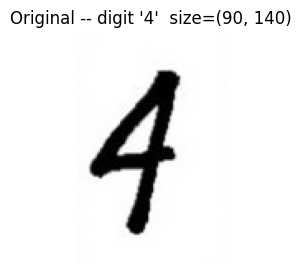

In [4]:
img_path = os.path.join(DATA_DIR, f"{digit_dropdown.value}.jpg")
assert os.path.exists(img_path), (
    f"Could not find {img_path} -- update DATA_DIR in the config cell above "
    f"to point at your folder of 0.jpg .. 9.jpg sample images."
)
original_img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(3, 3))
plt.imshow(original_img)
plt.title(f"Original -- digit '{digit_dropdown.value}'  size={original_img.size}")
plt.axis('off')
plt.show()


## Step 1 — Convert to grayscale

`RGB -> L` collapses the 3 color channels into 1 intensity channel. The real model actually keeps all 3 RGB channels as `conv1`'s input; we simplify to grayscale here purely so a single hand-made 3×3 kernel produces one clean, readable feature map next.

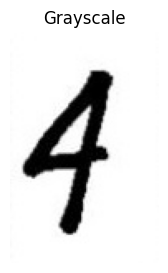

In [5]:
gray_img = original_img.convert("L")

plt.figure(figsize=(3, 3))
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()


## Step 2 — Resize to 28×28

Matches the exact input resolution the real `FCM_CNN` expects.

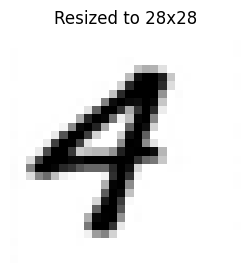

img_28 shape: (28, 28)   value range: [0.000, 1.000]


In [6]:
resized_img = gray_img.resize((28, 28))
img_28 = np.array(resized_img, dtype=np.float32) / 255.0

plt.figure(figsize=(3, 3))
plt.imshow(img_28, cmap='gray')
plt.title("Resized to 28x28")
plt.axis('off')
plt.show()
print(f"img_28 shape: {img_28.shape}   value range: [{img_28.min():.3f}, {img_28.max():.3f}]")


## Step 3 — 3×3 convolution → 1 feature map

A hand-crafted **outline / edge** kernel (Laplacian-style, weights sum to 0) stands in for `conv1`. Because it's a simple edge detector, the output stays visually close to the digit's shape -- "somewhat human-readable" as requested. Applied with `same` zero-padding so the output stays 28×28, exactly like `conv1` (`padding=1`) in the real model.

$$\text{output}[r,c] = \sum_{i,j}\ \text{patch}[i,j] \cdot \text{kernel}[i,j]$$

3x3 kernel (edge / outline detector):
[[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]


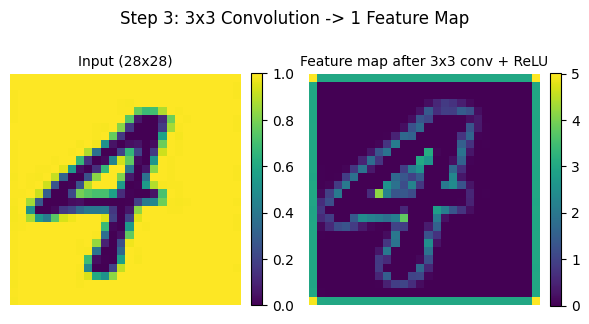

In [7]:
kernel_3x3 = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
], dtype=np.float32)
print("3x3 kernel (edge / outline detector):")
print(kernel_3x3)

fmap_3x3 = relu(conv2d(img_28, kernel_3x3))

show_maps([img_28, fmap_3x3],
          ["Input (28x28)", "Feature map after 3x3 conv + ReLU"],
          "Step 3: 3x3 Convolution -> 1 Feature Map")


In [8]:
_ = explain_conv_example(img_28, kernel_3x3, output=fmap_3x3)


Worked example -- output pixel at row=0, col=27

Input patch under the kernel (3x3):
[[0.    0.    0.   ]
 [1.    1.    0.   ]
 [1.    0.996 0.   ]]

Kernel weights (3x3):
[[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]

Element-wise product (patch * kernel):
[[-0.    -0.    -0.   ]
 [-1.     8.    -0.   ]
 [-1.    -0.996 -0.   ]]

Sum of all products -> output[0,27] = 5.0039

Formula:  output[r,c] = sum_i sum_j patch[i,j] * kernel[i,j]


## Step 4 — 2×2 max pool (28 → 14)

Each non-overlapping 2×2 block is replaced by its maximum value -- this is what shrinks the real model's 28×28 maps down to 14×14 after `conv1`.

$$\text{pooled}[r,c] = \max\big(\text{block}_{2\times2}\big)$$

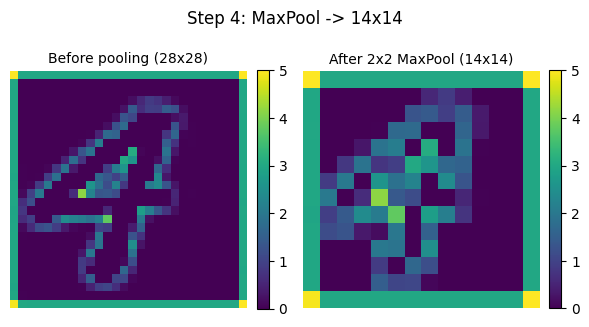

In [9]:
pooled_1 = maxpool2d(fmap_3x3, size=2, stride=2)

show_maps([fmap_3x3, pooled_1],
          ["Before pooling (28x28)", "After 2x2 MaxPool (14x14)"],
          "Step 4: MaxPool -> 14x14")


In [10]:
_ = explain_maxpool_example(fmap_3x3, pooled_1)


Worked example -- output pixel at row=0, col=13

2x2 block from the feature map:
[[3.004 5.004]
 [0.008 2.973]]

Max value in block = 5.0039  ->  pooled[0,13] = 5.0039

Formula:  pooled[r,c] = max over the corresponding size x size block of the input


## Step 5 — 5×5 convolution → 2 feature maps

Two hand-made 5×5 kernels stand in for `conv2` (which in the real model learns 128 such maps). Kernel **A** responds to horizontal edges, kernel **B** (its transpose) responds to vertical edges -- so together they highlight the horizontal and vertical strokes that make up the digit. `same` padding keeps the output 14×14, matching `conv2` (`padding=2`).

5x5 kernel A (horizontal-edge detector):
[[-2. -2. -4. -2. -2.]
 [-1. -1. -2. -1. -1.]
 [ 0.  0.  0.  0.  0.]
 [ 1.  1.  2.  1.  1.]
 [ 2.  2.  4.  2.  2.]]

5x5 kernel B (vertical-edge detector, transpose of A):
[[-2. -1.  0.  1.  2.]
 [-2. -1.  0.  1.  2.]
 [-4. -2.  0.  2.  4.]
 [-2. -1.  0.  1.  2.]
 [-2. -1.  0.  1.  2.]]


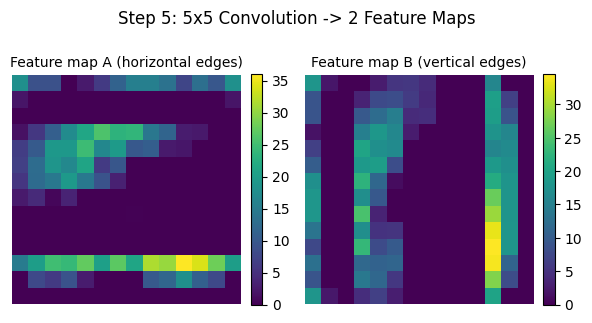

In [11]:
kernel_5x5_h = np.array([
    [-2, -2, -4, -2, -2],
    [-1, -1, -2, -1, -1],
    [ 0,  0,  0,  0,  0],
    [ 1,  1,  2,  1,  1],
    [ 2,  2,  4,  2,  2],
], dtype=np.float32)
kernel_5x5_v = kernel_5x5_h.T  # rotate 90 degrees -> vertical-edge detector

print("5x5 kernel A (horizontal-edge detector):")
print(kernel_5x5_h)
print("\n5x5 kernel B (vertical-edge detector, transpose of A):")
print(kernel_5x5_v)

fmap_5x5_a = relu(conv2d(pooled_1, kernel_5x5_h))
fmap_5x5_b = relu(conv2d(pooled_1, kernel_5x5_v))

show_maps([fmap_5x5_a, fmap_5x5_b],
          ["Feature map A (horizontal edges)", "Feature map B (vertical edges)"],
          "Step 5: 5x5 Convolution -> 2 Feature Maps")


In [12]:
_ = explain_conv_example(pooled_1, kernel_5x5_h, output=fmap_5x5_a)


Worked example -- output pixel at row=11, col=10

Input patch under the kernel (5x5):
[[0.012 0.    0.    0.    0.   ]
 [0.012 0.    0.    0.    0.   ]
 [0.012 0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.   ]
 [3.    3.    3.    3.    3.   ]]

Kernel weights (5x5):
[[-2. -2. -4. -2. -2.]
 [-1. -1. -2. -1. -1.]
 [ 0.  0.  0.  0.  0.]
 [ 1.  1.  2.  1.  1.]
 [ 2.  2.  4.  2.  2.]]

Element-wise product (patch * kernel):
[[-0.024 -0.    -0.    -0.    -0.   ]
 [-0.012 -0.    -0.    -0.    -0.   ]
 [ 0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.   ]
 [ 6.     6.    12.     6.     6.   ]]

Sum of all products -> output[11,10] = 35.9647

Formula:  output[r,c] = sum_i sum_j patch[i,j] * kernel[i,j]


## Step 6 — 2×2 max pool on both maps (14 → 7)

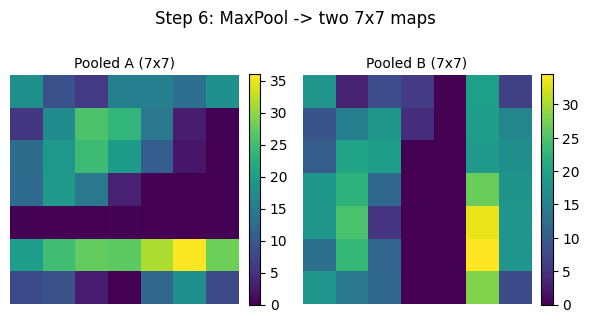

In [13]:
pooled_2a = maxpool2d(fmap_5x5_a)
pooled_2b = maxpool2d(fmap_5x5_b)

show_maps([pooled_2a, pooled_2b],
          ["Pooled A (7x7)", "Pooled B (7x7)"],
          "Step 6: MaxPool -> two 7x7 maps")


In [14]:
_ = explain_maxpool_example(fmap_5x5_a, pooled_2a)


Worked example -- output pixel at row=5, col=5

2x2 block from the feature map:
[[ 0.     0.   ]
 [35.965 33.996]]

Max value in block = 35.9647  ->  pooled[5,5] = 35.9647

Formula:  pooled[r,c] = max over the corresponding size x size block of the input


## Step 7 — 7×7 convolution → 4 feature maps (no pooling)

Stands in for `conv3` (`padding=3`, which the real model also leaves un-pooled). A real conv layer sums over *all* input channels before applying each kernel, so first we sum the two 7×7 maps from Step 6 into a single combined map, then apply **4 hand-made Gabor kernels** at four orientations (0°, 45°, 90°, 135°). Gabor filters are a classic hand-designed edge/texture detector, tuned to respond to lines at a specific angle:

$$g(x,y)=\exp\!\left(-\frac{x_\theta^2+\gamma^2y_\theta^2}{2\sigma^2}\right)\cos\!\left(\frac{2\pi x_\theta}{\lambda}\right)$$

These 4 maps are exactly the "given 4 feature maps" that feed into the FCM layer next -- matching `x` of shape `(B, 256, 7, 7)` in the real model, just with 4 channels instead of 256.

Combined 7x7 input (sum of the two channel maps):
[[35.859 12.416 14.157 21.525 15.51  32.576 24.624]
 [14.824 32.118 44.153 28.118 14.286 21.949 15.859]
 [22.914 39.329 43.898 19.584 10.784 20.776 17.188]
 [30.635 41.6   25.863  3.243  0.    26.576 17.894]
 [18.176 24.58   5.122  0.149  0.    33.416 17.945]
 [32.753 47.929 38.569 26.89  31.494 70.467 45.98 ]
 [25.984 23.106 14.251  0.129 11.808 45.988 16.008]]


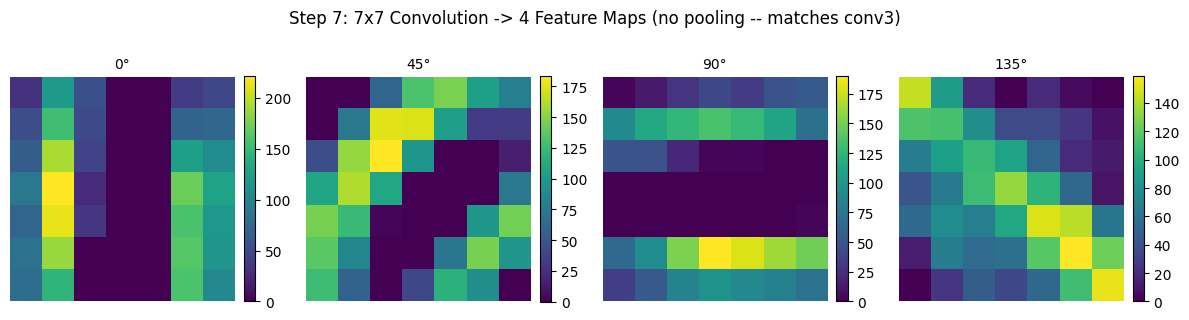


0-degree Gabor kernel weights:
[[-0.329 -0.491  0.238  0.835  0.238 -0.491 -0.329]
 [-0.364 -0.542  0.263  0.923  0.263 -0.542 -0.364]
 [-0.386 -0.576  0.28   0.98   0.28  -0.576 -0.386]
 [-0.394 -0.587  0.285  1.     0.285 -0.587 -0.394]
 [-0.386 -0.576  0.28   0.98   0.28  -0.576 -0.386]
 [-0.364 -0.542  0.263  0.923  0.263 -0.542 -0.364]
 [-0.329 -0.491  0.238  0.835  0.238 -0.491 -0.329]]


In [15]:
combined_input_7 = pooled_2a + pooled_2b  # sum over input channels, like a real conv layer does
print("Combined 7x7 input (sum of the two channel maps):")
print(np.round(combined_input_7, 3))

angles_deg = [0, 45, 90, 135]
kernels_7x7 = [gabor_kernel(7, np.deg2rad(a)) for a in angles_deg]

feat_maps_4 = [relu(conv2d(combined_input_7, k)) for k in kernels_7x7]

show_maps(feat_maps_4, [f"{a}\N{DEGREE SIGN}" for a in angles_deg],
          "Step 7: 7x7 Convolution -> 4 Feature Maps (no pooling -- matches conv3)")

print("\n0-degree Gabor kernel weights:")
print(np.round(kernels_7x7[0], 3))


In [16]:
_ = explain_conv_example(combined_input_7, kernels_7x7[0], output=feat_maps_4[0])


Worked example -- output pixel at row=3, col=1

Input patch under the kernel (7x7):
[[ 0.     0.    35.859 12.416 14.157 21.525 15.51 ]
 [ 0.     0.    14.824 32.118 44.153 28.118 14.286]
 [ 0.     0.    22.914 39.329 43.898 19.584 10.784]
 [ 0.     0.    30.635 41.6   25.863  3.243  0.   ]
 [ 0.     0.    18.176 24.58   5.122  0.149  0.   ]
 [ 0.     0.    32.753 47.929 38.569 26.89  31.494]
 [ 0.     0.    25.984 23.106 14.251  0.129 11.808]]

Kernel weights (7x7):
[[-0.329 -0.491  0.238  0.835  0.238 -0.491 -0.329]
 [-0.364 -0.542  0.263  0.923  0.263 -0.542 -0.364]
 [-0.386 -0.576  0.28   0.98   0.28  -0.576 -0.386]
 [-0.394 -0.587  0.285  1.     0.285 -0.587 -0.394]
 [-0.386 -0.576  0.28   0.98   0.28  -0.576 -0.386]
 [-0.364 -0.542  0.263  0.923  0.263 -0.542 -0.364]
 [-0.329 -0.491  0.238  0.835  0.238 -0.491 -0.329]]

Element-wise product (patch * kernel):
[[ -0.     -0.      8.544  10.37    3.373 -10.562  -5.102]
 [ -0.     -0.      3.903  29.648  11.627 -15.248  -5.193]
 [ -0

## Step 8 — Inside the FCM layer

`FCMLayer` treats every spatial location of the 4 feature maps as a point to be **soft-clustered**. Each of the `H*W = 49` locations becomes a 4-dimensional vector (one value per feature map); Fuzzy C-Means then groups these 49 vectors into `K` clusters, where each location gets a *fractional* (fuzzy) membership in every cluster rather than being forced into just one.

The three formulas being computed, for data point $n$ and cluster $k$:

**1. Distance** from a point to a cluster center:
$$d_{n,k} = \lVert x_n - c_k \rVert_2$$

**2. Fuzzy membership** (how strongly point $n$ belongs to cluster $k$; controlled by fuzziness $m$ -- larger $m$ gives softer, more blended memberships):
$$u_{n,k} = \dfrac{1}{\displaystyle\sum_{j=1}^{K}\left(\dfrac{d_{n,k}}{d_{n,j}}\right)^{\frac{2}{m-1}}}$$

**3. Center update** (weighted average of all points, weighted by their membership to that cluster):
$$c_k = \dfrac{\sum_{n=1}^{N} u_{n,k}^{m}\, x_n}{\sum_{n=1}^{N} u_{n,k}^{m}}$$

Steps 2 and 3 repeat for the chosen number of iterations. Finally, the maximum membership at each location becomes a soft **attention map** $A$, and the original 4 feature maps are refined by multiplying elementwise by $A$.

### Step 8a — Reshape the 4 feature maps into spatial vectors

In [17]:
stack_4 = np.stack(feat_maps_4, axis=0)          # (C=4, H=7, W=7)
C, H, W = stack_4.shape
X = stack_4.transpose(1, 2, 0).reshape(H * W, C)  # (N=49, C=4)

print(f"Stacked feature maps shape: {stack_4.shape}   (C={C} channels, H={H}, W={W})")
print(f"Reshaped spatial vectors X shape: {X.shape}   ({H*W} locations, each a {C}-dim vector)")

print("\nExample -- feature vector for spatial location (row=0, col=0):")
print(X[0])
print("(this is just [feature_map_0[0,0], feature_map_1[0,0], feature_map_2[0,0], feature_map_3[0,0]])")


Stacked feature maps shape: (4, 7, 7)   (C=4 channels, H=7, W=7)
Reshaped spatial vectors X shape: (49, 4)   (49 locations, each a 4-dim vector)

Example -- feature vector for spatial location (row=0, col=0):
[ 32.166386    0.          2.4982948 144.23073  ]
(this is just [feature_map_0[0,0], feature_map_1[0,0], feature_map_2[0,0], feature_map_3[0,0]])


### Step 8b — Initialize cluster centers

`K` random spatial locations are picked as the starting cluster centers (same random-init strategy as `FCMLayer.forward`).

K = 4 clusters initialized from these random spatial locations:
  flat index 21  ->  (row=3, col=0)   vector = [ 87.532 108.462   0.     42.058]
  flat index  4  ->  (row=0, col=4)   vector = [  0.    146.708  33.138  19.422]
  flat index 31  ->  (row=4, col=3)   vector = [ 0.     0.     0.    95.119]
  flat index 36  ->  (row=5, col=1)   vector = [186.997  84.294  92.548  66.941]


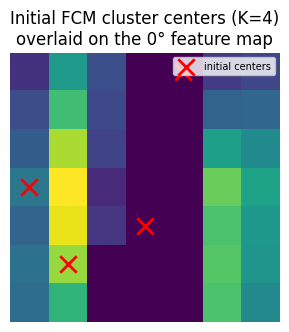

In [18]:
K = n_clusters_slider.value
rng = np.random.default_rng(42)
init_idx = rng.choice(H * W, size=K, replace=False)
centers = X[init_idx].copy()

print(f"K = {K} clusters initialized from these random spatial locations:")
for i in init_idx:
    print(f"  flat index {i:2d}  ->  (row={i // W}, col={i % W})   vector = {np.round(X[i], 3)}")

fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.imshow(feat_maps_4[0], cmap='viridis')
rows = [i // W for i in init_idx]
cols = [i % W for i in init_idx]
ax.scatter(cols, rows, c='red', s=140, marker='x', linewidths=2, label='initial centers')
ax.set_title(f"Initial FCM cluster centers (K={K})\noverlaid on the 0\N{DEGREE SIGN} feature map")
ax.legend(loc='upper right', fontsize=7)
ax.axis('off')
plt.show()


### Step 8c — Iteration 1, worked in full

The same three formulas from Step 8 are computed here for real numbers from this image, for one example location and one example cluster, so you can see exactly what the layer is doing.

In [19]:
n_iter = n_iter_slider.value
m = fuzziness_slider.value
eps = 1e-8
power = 2.0 / (m - 1.0)

print(f"Running FCM for n_iter={n_iter} iterations, fuzziness m={m}, K={K} clusters\n")

# ---- distance ----
dist = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=-1) + eps  # (N,K)

example_n, example_k = 0, 0
print(f"Worked example -- distance from location n={example_n} to center k={example_k}:")
print(f"  x_n = {np.round(X[example_n], 4)}")
print(f"  c_k = {np.round(centers[example_k], 4)}")
print(f"  d = ||x_n - c_k||_2 = {dist[example_n, example_k]:.4f}")

# ---- membership ----
ratio = dist[:, :, None] / dist[:, None, :]                      # (N,K,K)
u = 1.0 / (np.power(ratio, power).sum(axis=-1) + eps)             # (N,K)

print(f"\nWorked example -- membership of location n={example_n} to cluster k={example_k}:")
print(f"  distances from n={example_n} to all {K} centers: {np.round(dist[example_n], 4)}")
print(f"  u[{example_n},{example_k}] = 1 / sum_j (d_n,k / d_n,j)^(2/(m-1)) = {u[example_n, example_k]:.4f}")
print(f"  full membership vector for location {example_n}: {np.round(u[example_n], 4)}"
      f"  (sums to {u[example_n].sum():.4f} -- memberships always sum to 1)")

# ---- center update ----
um = np.power(u, m)
weighted_sum = um.T @ X
denom = um.sum(axis=0)[:, None] + eps
new_centers = weighted_sum / denom

print(f"\nWorked example -- updating center k={example_k}:")
print(f"  sum_n u[n,{example_k}]^m * x_n = {np.round(weighted_sum[example_k], 4)}")
print(f"  sum_n u[n,{example_k}]^m       = {denom[example_k, 0]:.4f}")
print(f"  new center c_{example_k} = {np.round(new_centers[example_k], 4)}")

centers = new_centers
U_history = [u.copy()]


Running FCM for n_iter=10 iterations, fuzziness m=2.0, K=4 clusters

Worked example -- distance from location n=0 to center k=0:
  x_n = [ 32.1664   0.       2.4983 144.2307]
  c_k = [ 87.5318 108.4623   0.      42.058 ]
  d = ||x_n - c_k||_2 = 158.9809

Worked example -- membership of location n=0 to cluster k=0:
  distances from n=0 to all 4 centers: [158.9809 197.6716  58.7611 212.5104]
  u[0,0] = 1 / sum_j (d_n,k / d_n,j)^(2/(m-1)) = 0.1050
  full membership vector for location 0: [0.105  0.0679 0.7684 0.0587]  (sums to 1.0000 -- memberships always sum to 1)

Worked example -- updating center k=0:
  sum_n u[n,0]^m * x_n = [525.8352 564.5985 160.7869 280.0305]
  sum_n u[n,0]^m       = 5.8662
  new center c_0 = [89.6387 96.2467 27.4092 47.7366]


### Step 8d — Remaining iterations

Same three steps, repeated for the remaining `n_iter - 1` iterations (no need to print every number again).

In [20]:
for it in range(1, n_iter):
    dist = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=-1) + eps
    ratio = dist[:, :, None] / dist[:, None, :]
    u = 1.0 / (np.power(ratio, power).sum(axis=-1) + eps)
    um = np.power(u, m)
    weighted_sum = um.T @ X
    denom = um.sum(axis=0)[:, None] + eps
    centers = weighted_sum / denom
    U_history.append(u.copy())

print(f"Completed {n_iter} iterations.")
print(f"Membership row-sums for the first 5 locations (should all be ~1): "
      f"{np.round(U_history[-1].sum(axis=1)[:5], 4)}")


Completed 10 iterations.
Membership row-sums for the first 5 locations (should all be ~1): [1. 1. 1. 1. 1.]


### Step 8e — Visualize how memberships evolve

Each cluster's membership values, reshaped back to 7×7, form a "membership map." Comparing iteration 1 to the final iteration shows the soft clusters sharpening and settling.

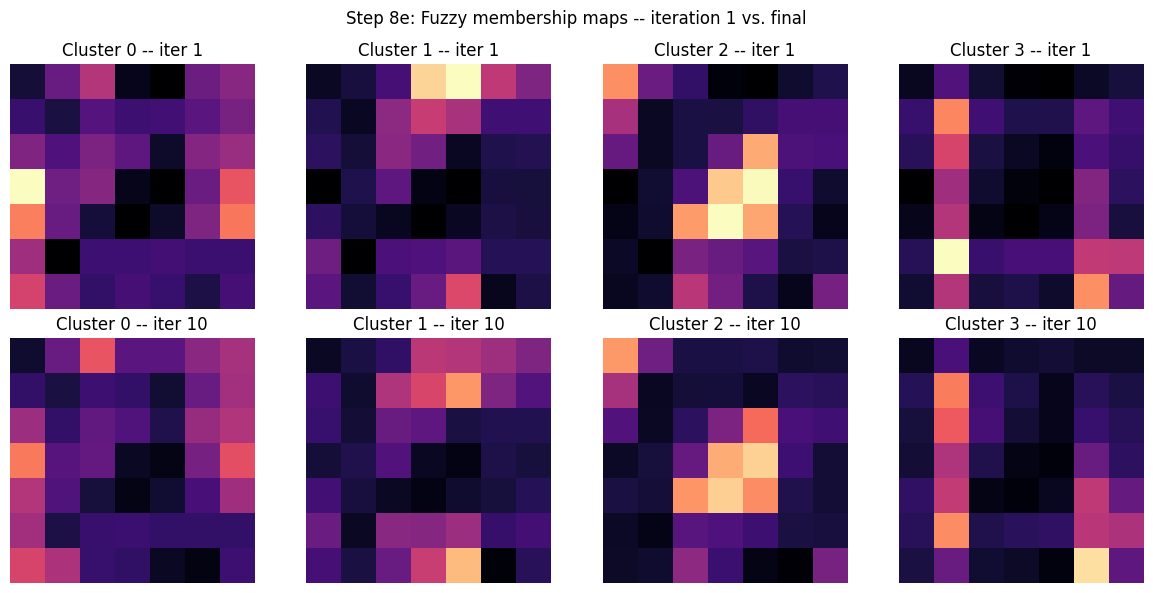

In [21]:
def memberships_to_maps(u, K, H, W):
    return [u[:, k].reshape(H, W) for k in range(K)]

maps_iter1 = memberships_to_maps(U_history[0], K, H, W)
maps_final = memberships_to_maps(U_history[-1], K, H, W)

fig, axes = plt.subplots(2, K, figsize=(3 * K, 6))
if K == 1:
    axes = axes.reshape(2, 1)
for k in range(K):
    axes[0, k].imshow(maps_iter1[k], cmap='magma', vmin=0, vmax=1)
    axes[0, k].set_title(f"Cluster {k} -- iter 1")
    axes[0, k].axis('off')
    axes[1, k].imshow(maps_final[k], cmap='magma', vmin=0, vmax=1)
    axes[1, k].set_title(f"Cluster {k} -- iter {n_iter}")
    axes[1, k].axis('off')
plt.suptitle("Step 8e: Fuzzy membership maps -- iteration 1 vs. final", fontsize=12)
plt.tight_layout()
plt.show()


### Step 8f — Build the attention map $A$

At every spatial location, take the *maximum* membership across all clusters. Locations that strongly belong to some cluster get a high attention value; ambiguous locations get a lower one.

$$A[r,c] = \max_k\ U_k[r,c]$$

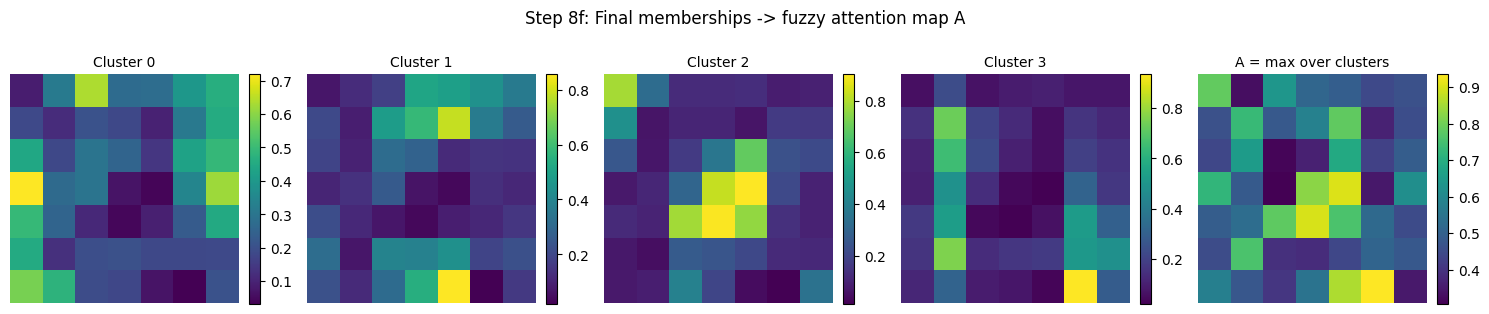

In [22]:
U_final = U_history[-1]
A = U_final.max(axis=1).reshape(H, W)

show_maps([*maps_final, A],
          [f"Cluster {k}" for k in range(K)] + ["A = max over clusters"],
          "Step 8f: Final memberships -> fuzzy attention map A")


### Step 8g — Refine the feature maps with attention

The last line of `FCM_CNN.forward`, `x_refined = x * A`, multiplies every one of the 4 feature maps elementwise by the same attention map $A$ -- amplifying spatial locations the fuzzy clustering found most distinctive, and suppressing the rest.

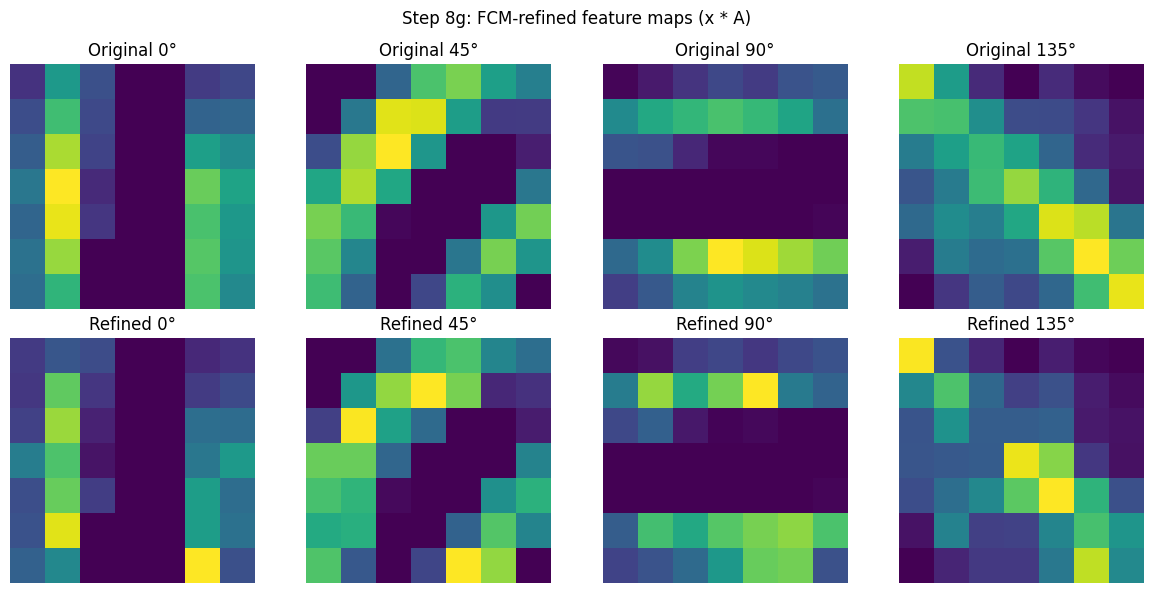

Example -- refining pixel (0,0) of the 0-degree feature map:
  original value        = 32.1664
  attention A[0,0]       = 0.7856
  refined = original * A = 25.2696


In [23]:
refined_maps = [feat_maps_4[c] * A for c in range(4)]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for c in range(4):
    axes[0, c].imshow(feat_maps_4[c], cmap='viridis')
    axes[0, c].set_title(f"Original {angles_deg[c]}\N{DEGREE SIGN}")
    axes[0, c].axis('off')
    axes[1, c].imshow(refined_maps[c], cmap='viridis')
    axes[1, c].set_title(f"Refined {angles_deg[c]}\N{DEGREE SIGN}")
    axes[1, c].axis('off')
plt.suptitle("Step 8g: FCM-refined feature maps (x * A)", fontsize=12)
plt.tight_layout()
plt.show()

print("Example -- refining pixel (0,0) of the 0-degree feature map:")
print(f"  original value        = {feat_maps_4[0][0, 0]:.4f}")
print(f"  attention A[0,0]       = {A[0, 0]:.4f}")
print(f"  refined = original * A = {refined_maps[0][0, 0]:.4f}")


## Recap

1. **Original → grayscale → 28×28** -- matches the real model's input pipeline.
2. **3×3 conv (1 map) → maxpool (14×14)** -- mirrors `conv1` + `pool1`.
3. **5×5 conv (2 maps) → maxpool (7×7)** -- mirrors `conv2` + `pool2`.
4. **7×7 conv (4 maps), no pooling** -- mirrors `conv3`, and is exactly the input the FCM layer receives.
5. **FCM layer**: reshape to spatial vectors → init centers → iterate {distance → membership → center update} → build attention map $A$ from max membership → refine feature maps by `x * A`.

Every kernel here was hand-picked for interpretability, but the shapes, padding, and the FCM math are identical to `fcm-cnn-digits.ipynb`. Change the digit dropdown or the FCM sliders near the top and re-run to explore how the attention map shifts.